<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week11/day3-4/GenAI_197_W11D3_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Download the data

In [ ]:
!wget "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip"

--2026-07-05 15:14:37--  https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip [following]
--2026-07-05 15:14:37--  https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 856265363 (817M) [application/zip]
Saving to: ‘Dogs vs Cats.zip’

Dogs vs Cats.zip    100%[===================>] 8

In [ ]:
# Unzipping the file
!unzip -q Dogs\ vs\ Cats.zip

In [ ]:
# !ls ./train/train
# !ls ./test/test

## Importing Libraries

In [ ]:
# Prefilled. Just copy and execute.
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


## Setting the file paths

In [ ]:
# Paths - change if needed
DATA_ROOT = Path(".")
train_dir = (DATA_ROOT / "train" / "train") if (DATA_ROOT / "train" / "train").exists() else (DATA_ROOT / "train")
test_dir  = (DATA_ROOT / "test"  / "test")  if (DATA_ROOT / "test"  / "test").exists()  else (DATA_ROOT / "test")

IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 32*4*2
seed = 41


In [ ]:
np.random.seed(seed); tf.random.set_seed(seed)
a = np.random.random()
a

0.25092362374494015

## Defining a function

In [ ]:
# Build DataFrames from folders
def build_df_from_folder(folder: Path, labeled: bool=True):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for ex in exts:
        files.extend(glob(str(folder / '**' / ex), recursive=True))
    if not files:
        raise FileNotFoundError(f"No images found under {folder}")
    rows = []
    for f in files:
        if labeled:
            name = Path(f).name.lower()
            parent = Path(f).parent.name.lower()
            if parent in {"cat","cats"}:
                label = "cat"
            elif parent in {"dog","dogs"}:
                label = "dog"
            else:
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name): label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name): label = "dog"
                else:
                    continue
            rows.append({"filepath": f, "label": label})
        else:
            rows.append({"filepath": f})
    return pd.DataFrame(rows)


In [ ]:
df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full  = build_df_from_folder(test_dir,  labeled=False)

## Train/Val split of the Training Dataset

In [ ]:
from sklearn.model_selection import train_test_split
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
)

## Image Generators (Data Augmentation)

In [ ]:
# Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

### Creating the flows from the generators

In [ ]:
train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)
val_flow = val_gen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False, validate_filenames=False
)
# Unlabeled test for inference only
test_flow = test_gen.flow_from_dataframe(
    df_test_full, x_col="filepath", y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None, batch_size=batch_size,
    shuffle=False, validate_filenames=False
)


Found 20000 non-validated image filenames belonging to 2 classes.
Found 5000 non-validated image filenames belonging to 2 classes.
Found 12500 non-validated image filenames.


In [ ]:
print({"train": train_flow.samples, "val": val_flow.samples, "test": test_flow.samples,
       "class_indices": train_flow.class_indices})

{'train': 20000, 'val': 5000, 'test': 12500, 'class_indices': {'cat': 0, 'dog': 1}}


## Data Inspection

Total training images per class: {'cat': np.int64(10000), 'dog': np.int64(10000)}


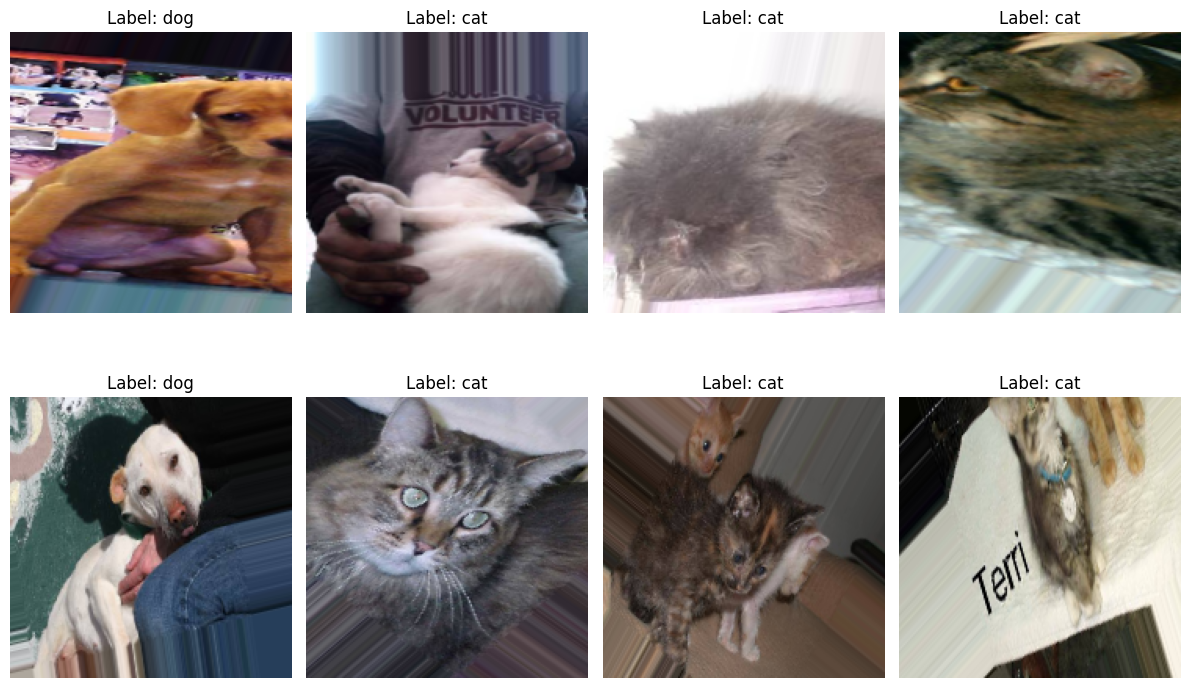

In [ ]:
import matplotlib.pyplot as plt

# 1. Data Distribution Description
class_indices = train_flow.class_indices
labels = train_flow.labels
unique, counts = np.unique(labels, return_counts=True)
class_counts = dict(zip(class_indices.keys(), counts))

print(f"Total training images per class: {class_counts}")
# Since there are 10,000 cats and 10,000 dogs, the classes are perfectly balanced.

# 2. Plotting a grid of images
plt.figure(figsize=(12, 8))
batch_x, batch_y = next(train_flow)

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(batch_x[i])
    label_idx = int(batch_y[i])
    label_name = list(class_indices.keys())[list(class_indices.values()).index(label_idx)]
    plt.title(f"Label: {label_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Visual Cues Explanation:
# The model likely relies on features such as the shape of the ears (pointed vs floppy),
# the length and shape of the snout, and the presence of whiskers or specific eye shapes
# to distinguish between cats and dogs.

## Defining the Model Architecture

- Convolution Layer
- MaxPooling
- Convolution
- MaxPooling
- Flattening
- ANN (1 hidden layer)
- Binary output using a sigmoid
-  Binary cross entropy is the correct loss to use

In [ ]:
from tensorflow.keras import layers, models

# Ensure GPU is used
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print('Found GPU at: {}'.format(device_name))

# Define the Model Architecture
model = models.Sequential([
    # First Convolution + MaxPooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolution + MaxPooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flattening
    layers.Flatten(),

    # ANN (1 hidden layer)
    layers.Dense(64, activation='relu'),

    # Binary output using a sigmoid
    layers.Dense(1, activation='sigmoid')
])

# Compile the model using Binary Cross Entropy loss
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Found GPU at: /device:GPU:0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 118336)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │     7,573,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,593,025 (28.97 MB)

 Trainable params: 7,593,025 (28.97 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Hyperparameters
# Initial learning rate of 0.001 is reasonable as it's the standard for Adam,
# providing a good balance between speed and stability.
initial_lr = 1e-3 #0.0001
# Batch size of 32 is efficient for the current image size (180x180) on standard GPU memory.

# 2. Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Re-compile with specific learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Model Training
history = model.fit(
    train_flow,
    epochs=20,
    validation_data=val_flow,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.5784 - loss: 0.7560 - val_accuracy: 0.6492 - val_loss: 0.6202 - learning_rate: 0.0010
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.6573 - loss: 0.6144 - val_accuracy: 0.7054 - val_loss: 0.5740 - learning_rate: 0.0010
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.6852 - loss: 0.5845 - val_accuracy: 0.7114 - val_loss: 0.5635 - learning_rate: 0.0010
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.6952 - loss: 0.5759 - val_accuracy: 0.7154 - val_loss: 0.5602 - learning_rate: 0.0010
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 208s 3s/step - accuracy: 0.7088 - loss: 0.5613 - val_accuracy: 0.7392 - val_loss: 0.5181 - learning_rate: 0.0010
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.7095 - loss: 0.5551 - val_accuracy: 0.7522 - val_loss: 0.4977 - learning_rate: 0.0010
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.7235 - loss: 0.5402 - val_acc

## Plotting the Learning Curves

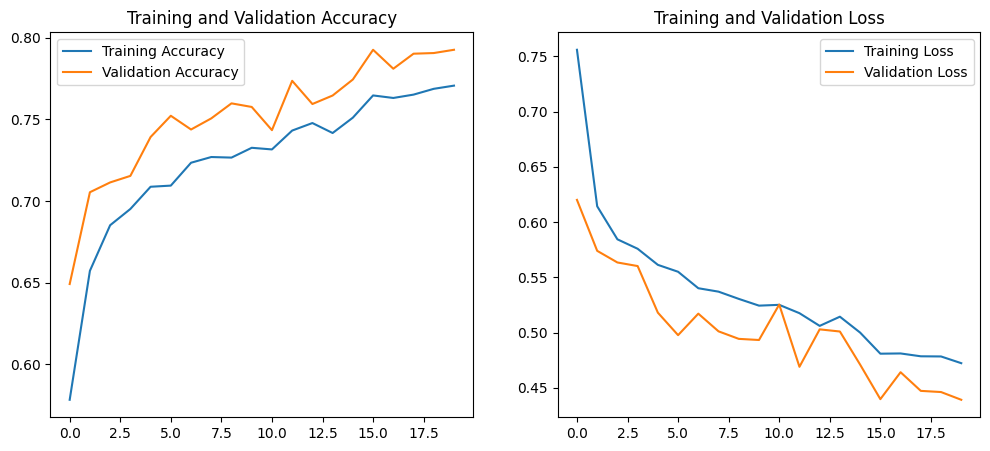

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 489ms/step


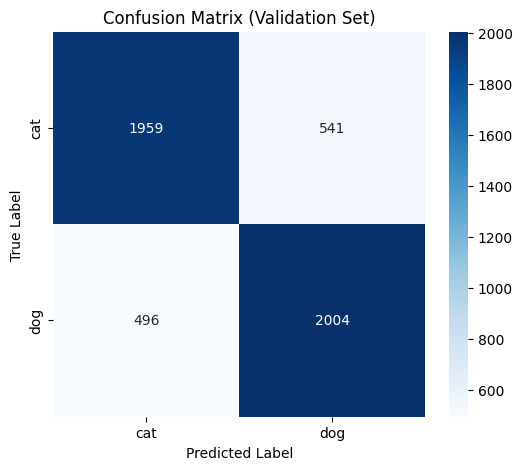

Classification Report:
              precision    recall  f1-score   support

         cat       0.80      0.78      0.79      2500
         dog       0.79      0.80      0.79      2500

    accuracy                           0.79      5000
   macro avg       0.79      0.79      0.79      5000
weighted avg       0.79      0.79      0.79      5000



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Plot Learning Curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# 2. Confusion Matrix and Classification Report
val_flow.reset()
y_pred_probs = model.predict(val_flow)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = val_flow.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(class_indices.keys()),
            yticklabels=list(class_indices.keys()))
plt.title('Confusion Matrix (Validation Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(class_indices.keys())))


## Testing Confidence levels of the preditions on the Test DS

In [ ]:
# 1. Generate probabilities for the test set
test_flow.reset()
probs = model.predict(test_flow)

# 2. Convert probabilities to labels
# Threshold justification: Since the classes are balanced and we are performing binary classification
# with a sigmoid output, 0.5 is the most reasonable decision boundary to separate the two classes.
threshold = 0.5
pred_labels = ["dog" if p > threshold else "cat" for p in probs]

# 3. Create DataFrame and save to CSV
df_results = pd.DataFrame({
    "filepath": df_test_full["filepath"],
    "prob_dog": probs.flatten(),
    "pred_label": pred_labels
})

df_results.to_csv("test_predictions.csv", index=False)
print("Saved test_predictions.csv with columns: filepath, prob_dog, pred_label")

# Display the first few results
df_results.head()

49/49 ━━━━━━━━━━━━━━━━━━━━ 33s 664ms/step
Saved test_predictions.csv with columns: filepath, prob_dog, pred_label


,filepath,prob_dog,pred_label
0,test/test/4332.jpg,0.944531,dog
1,test/test/9495.jpg,0.922071,dog
2,test/test/4856.jpg,0.764890,dog
3,test/test/12341.jpg,0.977076,dog
4,test/test/10070.jpg,0.817234,dog


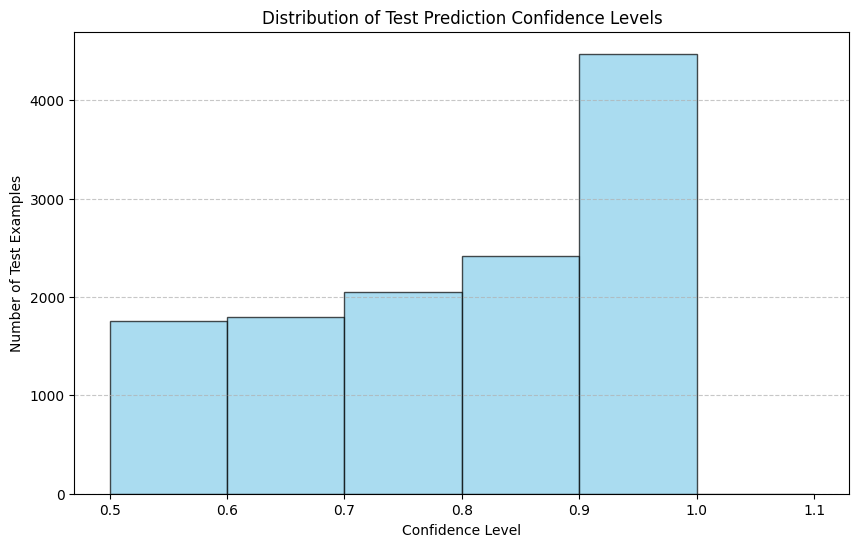

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate confidence levels
# Confidence is the probability of the predicted class
# If pred is 'dog', confidence is prob_dog. If 'cat', it's 1 - prob_dog.
confidences = df_results.apply(lambda row: row['prob_dog'] if row['pred_label'] == 'dog' else 1 - row['prob_dog'], axis=1)

# Define the bins from 0.5 to 1.0
bins = np.arange(0.5, 1.1, 0.1)

plt.figure(figsize=(10, 6))
plt.hist(confidences, bins=bins, edgecolor='black', color='skyblue', alpha=0.7)

plt.title('Distribution of Test Prediction Confidence Levels')
plt.xlabel('Confidence Level')
plt.ylabel('Number of Test Examples')
plt.xticks(bins)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Display a few examples of test pictures, and their predicted label (grid of 3x3)

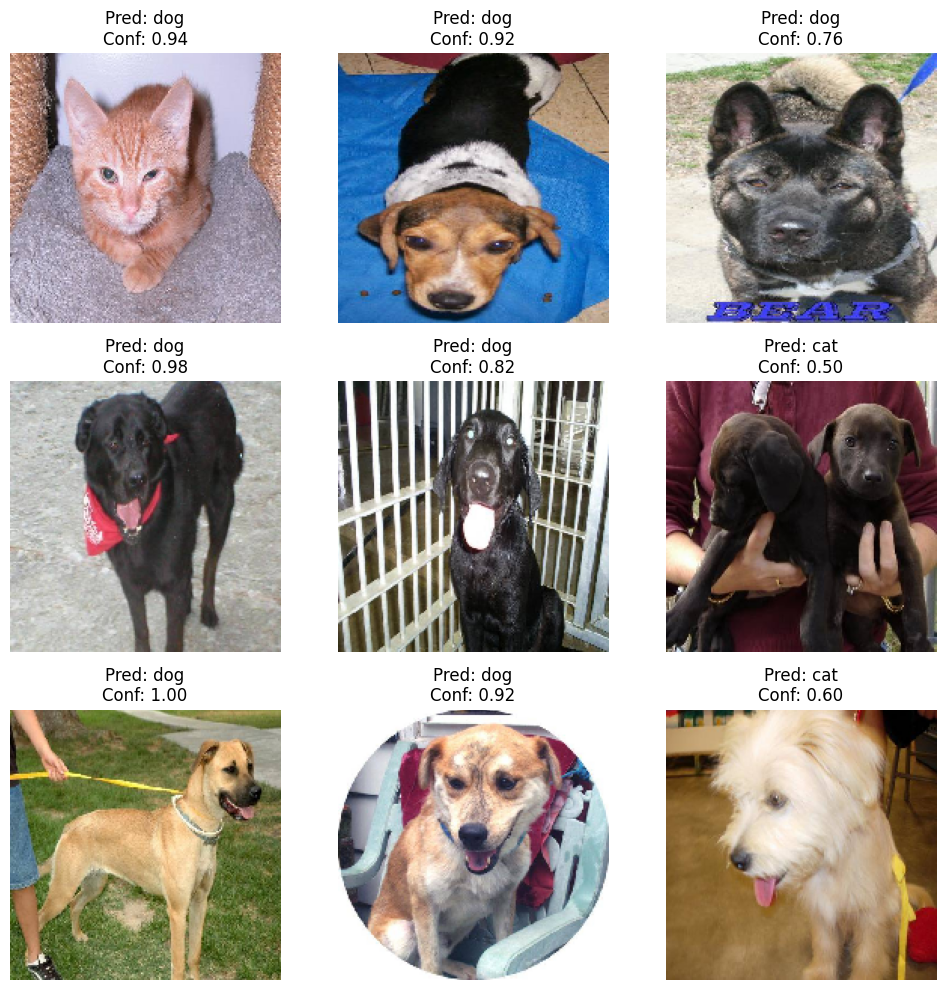

In [ ]:
import matplotlib.pyplot as plt

# Retrieve a batch of test images
test_flow.reset()
batch_x = next(test_flow)
# Get the corresponding predictions from our saved results
# Since shuffle=False in test_flow, the order matches df_results

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(batch_x[i])
    pred_label = df_results.iloc[i]['pred_label']
    confidence = df_results.iloc[i]['prob_dog']
    # Display 'dog' probability if dog, or 'cat' probability (1-prob_dog)
    score = confidence if pred_label == 'dog' else 1 - confidence
    plt.title(f"Pred: {pred_label}\nConf: {score:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()